<a href="https://colab.research.google.com/github/isabela2206/lia1_2026_2/blob/main/Entregas%20-%20Isabela%20Campos/Projeto%204%20-%20Detector%20YOLO11%20ONNX/detector_yolo11_onnx_pt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detector de Objetos com PyTorch + YOLO11 + ONNX

**Objetivo:** utilizar um modelo YOLO11n baseado em PyTorch, pré-treinado no COCO, realizar detecção de objetos com bounding boxes, apresentar as 80 classes em português e exportar o detector para ONNX.

**Fluxo:** Imagem → YOLO11/PyTorch → Detecção → Classe em português + Confiança + Bounding Box → ONNX

> Traduzir os nomes das classes não altera o conhecimento aprendido pelo modelo. O detector continua usando os IDs das 80 classes COCO; neste notebook associamos esses IDs aos respectivos nomes em português.

## 1. Instalação das dependências

In [ ]:
!pip install -q ultralytics onnx onnxruntime onnxslim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.0/239.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 6.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
ydf 0.15.0 requir

## 2. Importações e verificação do ambiente

In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
import torch
import onnxruntime as ort
import ultralytics
from ultralytics import YOLO
from PIL import Image, ImageDraw, ImageFont
from matplotlib import font_manager
from IPython.display import display

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("ONNX Runtime:", ort.__version__)
print("GPU disponível:", torch.cuda.is_available())

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics: 8.4.157
PyTorch: 2.11.0+cpu
ONNX Runtime: 1.30.0
GPU disponível: False


## 3. Carregamento do modelo YOLO11n pré-treinado no COCO
O arquivo `yolo11n.pt` é baixado automaticamente na primeira execução.

In [ ]:
model = YOLO("yolo11n.pt")

print("Tipo do modelo interno:", type(model.model).__name__)
print("Número de classes:", len(model.names))
print("Exemplo de classes (inglês):", [model.names[i] for i in range(5)])

Tipo do modelo interno: DetectionModel
Número de classes: 80
Exemplo de classes (inglês): ['person', 'bicycle', 'car', 'motorcycle', 'airplane']


## 4. Tradução das 80 classes COCO para português
A tradução é feita pelo **nome em inglês** retornado pelo próprio modelo, e a lista final é montada **na ordem dos IDs** (0 a 79).

In [ ]:
traducao = {
    "person": "pessoa", "bicycle": "bicicleta", "car": "carro", "motorcycle": "motocicleta",
    "airplane": "avião", "bus": "ônibus", "train": "trem", "truck": "caminhão",
    "boat": "barco", "traffic light": "semáforo", "fire hydrant": "hidrante",
    "stop sign": "placa de pare", "parking meter": "parquímetro", "bench": "banco",
    "bird": "pássaro", "cat": "gato", "dog": "cachorro", "horse": "cavalo",
    "sheep": "ovelha", "cow": "vaca", "elephant": "elefante", "bear": "urso",
    "zebra": "zebra", "giraffe": "girafa", "backpack": "mochila", "umbrella": "guarda-chuva",
    "handbag": "bolsa", "tie": "gravata", "suitcase": "mala", "frisbee": "frisbee",
    "skis": "esquis", "snowboard": "snowboard", "sports ball": "bola",
    "kite": "pipa", "baseball bat": "taco de beisebol", "baseball glove": "luva de beisebol",
    "skateboard": "skate", "surfboard": "prancha de surfe", "tennis racket": "raquete de tênis",
    "bottle": "garrafa", "wine glass": "taça de vinho", "cup": "copo", "fork": "garfo",
    "knife": "faca", "spoon": "colher", "bowl": "tigela", "banana": "banana",
    "apple": "maçã", "sandwich": "sanduíche", "orange": "laranja", "broccoli": "brócolis",
    "carrot": "cenoura", "hot dog": "cachorro-quente", "pizza": "pizza", "donut": "rosquinha",
    "cake": "bolo", "chair": "cadeira", "couch": "sofá", "potted plant": "vaso de planta",
    "bed": "cama", "dining table": "mesa de jantar", "toilet": "vaso sanitário",
    "tv": "televisão", "laptop": "notebook", "mouse": "mouse", "remote": "controle remoto",
    "keyboard": "teclado", "cell phone": "celular", "microwave": "micro-ondas",
    "oven": "forno", "toaster": "torradeira", "sink": "pia", "refrigerator": "geladeira",
    "book": "livro", "clock": "relógio", "vase": "vaso", "scissors": "tesoura",
    "teddy bear": "ursinho de pelúcia", "hair drier": "secador de cabelo",
    "toothbrush": "escova de dentes",
}

faltando = [n for n in model.names.values() if n not in traducao]
assert not faltando, f"Classes sem tradução: {faltando}"

classes_pt = [traducao[model.names[i]] for i in range(len(model.names))]
assert len(classes_pt) == 80
print("Tradução completa:", len(classes_pt), "classes")

Tradução completa: 80 classes


## 5. Tabela ID → classe

In [ ]:
tabela = pd.DataFrame({
    "ID": range(80),
    "Classe (inglês)": [model.names[i] for i in range(80)],
    "Classe (português)": classes_pt,
})
pd.set_option("display.max_rows", 80)
tabela

,ID,Classe (inglês),Classe (português)
0,0,person,pessoa
1,1,bicycle,bicicleta
2,2,car,carro
3,3,motorcycle,motocicleta
4,4,airplane,avião
5,5,bus,ônibus
6,6,train,trem
7,7,truck,caminhão
8,8,boat,barco
9,9,traffic light,semáforo


## 6. Salvando `classes_coco80_pt.txt`
Uma classe por linha: a linha 1 corresponde ao ID 0, a linha 80 ao ID 79.

In [ ]:
ARQ_CLASSES = "classes_coco80_pt.txt"
with open(ARQ_CLASSES, "w", encoding="utf-8") as f:
    f.write("\n".join(classes_pt) + "\n")

!head -n 5 classes_coco80_pt.txt
!wc -l classes_coco80_pt.txt

pessoa
bicicleta
carro
motocicleta
avião
80 classes_coco80_pt.txt


## 7. Imagem de teste
Por padrão baixa uma imagem de exemplo. Para usar sua própria imagem, troque `USAR_UPLOAD = True`.

Imagem: teste.jpg | tamanho: (810, 1080)


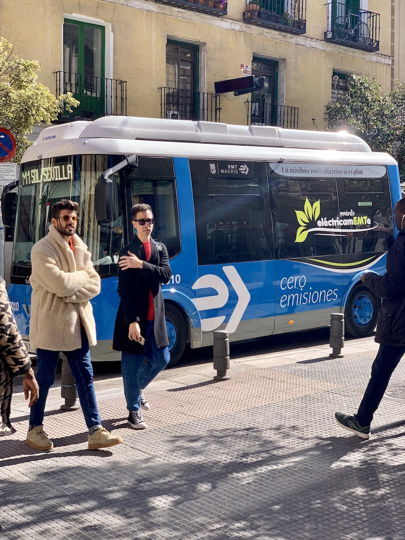

In [ ]:
USAR_UPLOAD = False

if USAR_UPLOAD:
    from google.colab import files
    enviado = files.upload()
    IMAGEM = list(enviado.keys())[0]
else:
    !wget -q https://ultralytics.com/images/bus.jpg -O teste.jpg
    IMAGEM = "teste.jpg"

img_original = Image.open(IMAGEM).convert("RGB")
print("Imagem:", IMAGEM, "| tamanho:", img_original.size)
display(img_original.resize((img_original.width // 2, img_original.height // 2)))

## 8. Função de desenho com nomes em português
Usamos PIL com a fonte DejaVu Sans porque o `cv2.putText` não desenha acentos (ã, ç, ô...).

In [ ]:
FONTE = ImageFont.truetype(font_manager.findfont("DejaVu Sans"), 18)
CORES = np.random.default_rng(42).integers(60, 255, size=(80, 3))

def desenhar(img_pil, deteccoes):
    img = img_pil.copy()
    d = ImageDraw.Draw(img)
    for det in deteccoes:
        cor = tuple(int(c) for c in CORES[det["id"]])
        x1, y1, x2, y2 = det["caixa"]
        d.rectangle([x1, y1, x2, y2], outline=cor, width=3)
        texto = f'{det["classe"]} {det["conf"]:.0%}'
        alt = d.textbbox((0, 0), texto, font=FONTE)[3]
        ty = max(0, y1 - alt - 6)
        tb = d.textbbox((x1 + 3, ty), texto, font=FONTE)
        d.rectangle([tb[0] - 3, tb[1] - 3, tb[2] + 3, tb[3] + 3], fill=cor)
        d.text((x1 + 3, ty), texto, fill=(0, 0, 0), font=FONTE)
    return img

def tabela_deteccoes(deteccoes):
    return pd.DataFrame([{
        "ID": d["id"], "Classe": d["classe"], "Confiança": f'{d["conf"]:.1%}',
        "x1": round(d["caixa"][0]), "y1": round(d["caixa"][1]),
        "x2": round(d["caixa"][2]), "y2": round(d["caixa"][3]),
    } for d in deteccoes])

## 9. Detecção com YOLO11n / PyTorch

PyTorch: 5 objetos detectados


,ID,Classe,Confiança,x1,y1,x2,y2
0,5,ônibus,94.0%,4,229,796,728
1,0,pessoa,88.8%,671,395,810,879
2,0,pessoa,87.8%,47,400,239,904
3,0,pessoa,85.6%,223,409,344,860
4,0,pessoa,62.2%,0,556,69,872


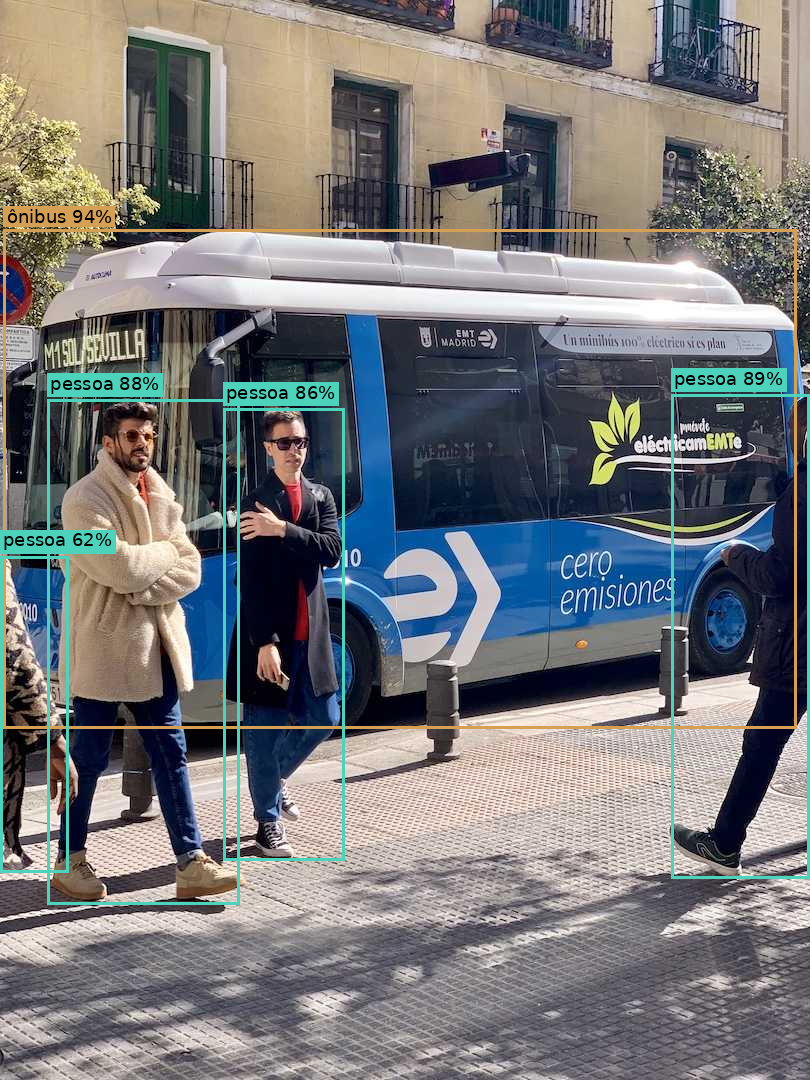

In [ ]:
CONF_MIN = 0.25
IOU_NMS = 0.45

resultado = model.predict(IMAGEM, conf=CONF_MIN, iou=IOU_NMS, imgsz=640, verbose=False)[0]

det_pytorch = []
for box in resultado.boxes:
    cid = int(box.cls)
    det_pytorch.append({
        "id": cid,
        "classe": classes_pt[cid],
        "conf": float(box.conf),
        "caixa": tuple(box.xyxy[0].tolist()),
    })

print(f"PyTorch: {len(det_pytorch)} objetos detectados")
display(tabela_deteccoes(det_pytorch))
display(desenhar(img_original, det_pytorch))

## 10. Exportação para ONNX

In [ ]:
caminho_onnx = model.export(format="onnx", imgsz=640, dynamic=False, simplify=True)
print("Arquivo gerado:", caminho_onnx)
print(f"Tamanho: {os.path.getsize(caminho_onnx) / 1e6:.1f} MB")

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

PyTorch: starting from 'yolo11n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.4 MB)

ONNX: starting export with onnx 1.23.0 opset 18...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 1.3s, saved as 'yolo11n.onnx' (10.2 MB)

Export complete (2.1s)
Results saved to /content/yolo11n.onnx
Predict:         yolo predict task=detect model=yolo11n.onnx imgsz=640 
Validate:        yolo val task=detect model=yolo11n.onnx imgsz=640 data=/usr/src/ultralytics/ultralytics/cfg/datasets/coco.yaml  
Visualize:       https://netron.app
Arquivo gerado: yolo11n.onnx
Tamanho: 10.7 MB


## 11. Inspeção do modelo ONNX
Saída esperada `(1, 84, 8400)`: 8400 caixas candidatas, cada uma com 4 coordenadas (`cx, cy, w, h`) + 80 scores de classe.

In [ ]:
sessao = ort.InferenceSession(caminho_onnx, providers=["CPUExecutionProvider"])

for e in sessao.get_inputs():
    print("Entrada:", e.name, e.shape, e.type)
for s in sessao.get_outputs():
    print("Saída:  ", s.name, s.shape, s.type)

Entrada: images [1, 3, 640, 640] tensor(float)
Saída:   output0 [1, 84, 8400] tensor(float)


## 12. Pré e pós-processamento para o ONNX
No ONNX nada vem pronto: precisamos fazer o *letterbox*, a normalização, o filtro de confiança, o **NMS** e a reescala das caixas. É exatamente isso que o aplicativo de inferência também precisará fazer.

In [ ]:
def letterbox(img, novo=640, cor=(114, 114, 114)):
    h, w = img.shape[:2]
    r = min(novo / h, novo / w)
    nh, nw = round(h * r), round(w * r)
    redim = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_LINEAR)
    topo, esq = (novo - nh) // 2, (novo - nw) // 2
    tela = np.full((novo, novo, 3), cor, dtype=np.uint8)
    tela[topo:topo + nh, esq:esq + nw] = redim
    return tela, r, esq, topo

def pre_processar(img_pil):
    rgb = np.array(img_pil)                              # RGB, HxWx3
    lb, r, esq, topo = letterbox(rgb)
    x = lb.astype(np.float32) / 255.0                    # 0..1
    x = np.transpose(x, (2, 0, 1))[None]                 # 1x3x640x640
    return x, r, esq, topo

def pos_processar(saida, r, esq, topo, largura, altura, conf_min=0.25, iou=0.45):
    pred = saida[0].T                                    # 8400 x 84
    caixas, scores = pred[:, :4], pred[:, 4:]
    ids = scores.argmax(axis=1)
    confs = scores.max(axis=1)

    m = confs >= conf_min
    caixas, ids, confs = caixas[m], ids[m], confs[m]
    if len(caixas) == 0:
        return []

    # cx, cy, w, h (espaço 640) -> x, y, w, h (espaço da imagem original)
    x = (caixas[:, 0] - caixas[:, 2] / 2 - esq) / r
    y = (caixas[:, 1] - caixas[:, 3] / 2 - topo) / r
    w = caixas[:, 2] / r
    h = caixas[:, 3] / r
    xywh = np.stack([x, y, w, h], axis=1)

    # NMS por classe
    manter = cv2.dnn.NMSBoxesBatched(xywh.tolist(), confs.tolist(), ids.tolist(), conf_min, iou)
    manter = np.array(manter).flatten()

    deteccoes = []
    for i in manter:
        x1 = float(np.clip(xywh[i, 0], 0, largura))
        y1 = float(np.clip(xywh[i, 1], 0, altura))
        x2 = float(np.clip(xywh[i, 0] + xywh[i, 2], 0, largura))
        y2 = float(np.clip(xywh[i, 1] + xywh[i, 3], 0, altura))
        cid = int(ids[i])
        deteccoes.append({"id": cid, "classe": classes_pt[cid],
                          "conf": float(confs[i]), "caixa": (x1, y1, x2, y2)})
    return sorted(deteccoes, key=lambda d: -d["conf"])

## 13. Detecção usando apenas o ONNX + `classes_coco80_pt.txt`
Aqui simulamos o aplicativo: as classes são lidas do arquivo `.txt`, não do modelo PyTorch.

ONNX: 5 objetos detectados


,ID,Classe,Confiança,x1,y1,x2,y2
0,5,ônibus,93.9%,12,228,799,735
1,0,pessoa,90.2%,49,398,243,905
2,0,pessoa,84.9%,671,393,810,880
3,0,pessoa,83.3%,223,406,345,860
4,0,pessoa,39.9%,0,550,66,872


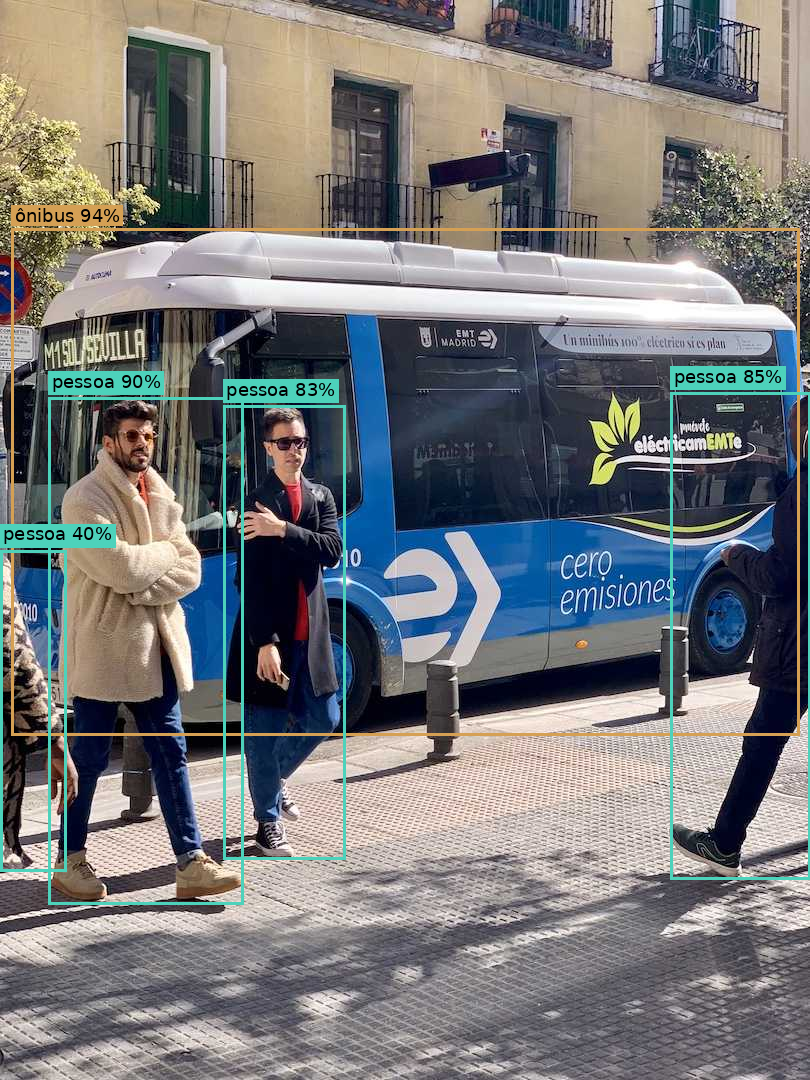

In [ ]:
with open(ARQ_CLASSES, encoding="utf-8") as f:
    classes_pt = [linha.strip() for linha in f if linha.strip()]

entrada, r, esq, topo = pre_processar(img_original)
saida = sessao.run(None, {sessao.get_inputs()[0].name: entrada})[0]

det_onnx = pos_processar(saida, r, esq, topo, *img_original.size,
                         conf_min=CONF_MIN, iou=IOU_NMS)

print(f"ONNX: {len(det_onnx)} objetos detectados")
display(tabela_deteccoes(det_onnx))
display(desenhar(img_original, det_onnx))

## 14. Comparação PyTorch × ONNX
As contagens por classe devem ser iguais (pequenas diferenças de confiança são normais).

In [ ]:
from collections import Counter

c_pt = Counter(d["classe"] for d in det_pytorch)
c_ox = Counter(d["classe"] for d in det_onnx)
comp = pd.DataFrame({"PyTorch": c_pt, "ONNX": c_ox}).fillna(0).astype(int)
display(comp)
print("Resultados equivalentes:", c_pt == c_ox)

,PyTorch,ONNX
ônibus,1,1
pessoa,4,4


Resultados equivalentes: True


## 15. Download dos arquivos para o aplicativo

In [ ]:
desenhar(img_original, det_pytorch).save("resultado_pytorch.jpg")
desenhar(img_original, det_onnx).save("resultado_onnx.jpg")

!zip -q detector_coco80_pt.zip yolo11n.onnx classes_coco80_pt.txt resultado_pytorch.jpg resultado_onnx.jpg

from google.colab import files
files.download("detector_coco80_pt.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Resultado

Ao final deste notebook temos um detector capaz de reconhecer as 80 classes COCO, com apresentação dos nomes em português.

**Fluxo estudado:** Imagem → YOLO11n / PyTorch → Detecção de objetos → Classe + Confiança + Bounding Box → Exportação ONNX

**Importante:** o modelo continua reconhecendo as mesmas 80 categorias aprendidas no COCO. A tradução altera apenas a forma como os nomes das classes são apresentados.

Para o aplicativo **Inferência Universal de Imagens**, utilizar:
- `yolo11n.onnx` para realizar a inferência;
- `classes_coco80_pt.txt` para associar cada ID ao nome da classe em português.

**Próximo passo possível:** um detector especializado (capacete | sem capacete | colete | luva | celular), treinando o YOLO11n com um dataset próprio anotado com essas classes. O pipeline de exportação continua o mesmo; muda o número de classes na saída (`4 + 5 = 9`) e o arquivo `.txt`.